In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# 1. Load the data
# Ensure the CSV file is in the same folder as your notebook
df = pd.read_csv('spreadspoke_scores.csv')

In [24]:
# 2. Data Cleaning & Preparation
# Filter for regular season and playoff games, excluding neutral sites (like London or Super Bowls)
df_clean = df[df['stadium_neutral'] == False].copy()

# Create the Home Margin metric: (Home Score - Away Score)
# A positive number indicates a Home Team win/advantage
# Calculates the point difference for the home team by subtracting the away score from the home score and stores it in a new column called home_margin.
df_clean['home_margin'] = df_clean['score_home'] - df_clean['score_away']

# Creates a boolean (True/False) column called home_win that identifies if the home team won (where the margin is greater than zero).
df_clean['home_win'] = df_clean['home_margin'] > 0

In [25]:
# 3. Visuals
# # Aggregating by Season
# We want to see the average margin and win percentage per year
# Groups the cleaned data by the football season and calculates the "mean" (average) for both the home_margin and the home_win percentage for every year.
seasonal_trends = df_clean.groupby('schedule_season').agg({
    'home_margin': 'mean',
    'home_win': 'mean'
}).reset_index()

In [26]:
# Using existing df_clean (which already filters out neutral sites)
# Calculates the total number of rows (games) in your cleaned dataset.
total_games = len(df_clean)

# 2. Calculate raw counts for Wins, Losses, and Ties
# Compares the home score to the away score for every game and counts how many times the home team won.
home_wins = (df_clean['score_home'] > df_clean['score_away']).sum()

#Compares the scores and counts how many times the home team lost.
home_losses = (df_clean['score_home'] < df_clean['score_away']).sum()

#Counts how many games ended with identical scores (ties)
home_ties = (df_clean['score_home'] == df_clean['score_away']).sum()

In [27]:
# Calculate Percentages
#Divides the number of wins by the total games and multiplies by 100 to get a percentage.
win_pct = (home_wins / total_games) * 100

#Performs the same calculation to find the percentage of losses and ties.
loss_pct = (home_losses / total_games) * 100
tie_pct = (home_ties / total_games) * 100

In [28]:
# Print results for your Section 5 (Storytelling)
print(f"Analysis of {total_games:,} Non-Neutral NFL Games (1966-Present):")
print("-" * 50)

# Displays the calculated win percentage
print(f"Home Team Win Percentage:  {win_pct:.2f}%")
print(f"Home Team Loss Percentage: {loss_pct:.2f}%")
print(f"Home Team Tie Percentage:  {tie_pct:.2f}%")

Analysis of 14,240 Non-Neutral NFL Games (1966-Present):
--------------------------------------------------
Home Team Win Percentage:  57.05%
Home Team Loss Percentage: 42.31%
Home Team Tie Percentage:  0.64%


C:\Users\Jacob.Makowski\AppData\Local\Temp\ipykernel_5116\1734091569.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcomes, y=percentages, palette=['#4CAF50', '#F44336', '#9E9E9E'])


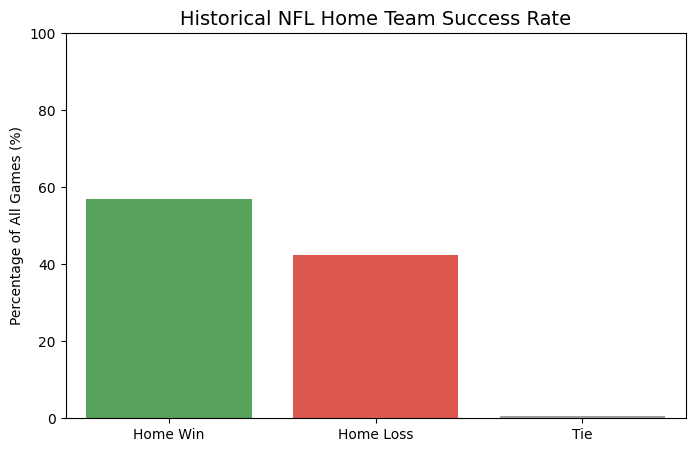

In [29]:
# Visual comparison of total outcomes
# Sets the dimensions of the bar chart to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

# Creates a list of labels for the x-axis of the chart
outcomes = ['Home Win', 'Home Loss', 'Tie']

# : Creates a list containing the corresponding numerical values for each label.
percentages = [win_pct, loss_pct, tie_pct]

#Generates a bar plot showing the three different outcome percentages using the "viridis" color theme
sns.barplot(x=outcomes, y=percentages, palette=['#4CAF50', '#F44336', '#9E9E9E'])

plt.title('Historical NFL Home Team Success Rate', fontsize=14)
plt.ylabel('Percentage of All Games (%)')

#  Sets the vertical (y) axis scale from 0 to 100. This is important so the viewer can see the full context of the percentages.
plt.ylim(0, 100) # Set to 100 to show the scale clearly
plt.show()

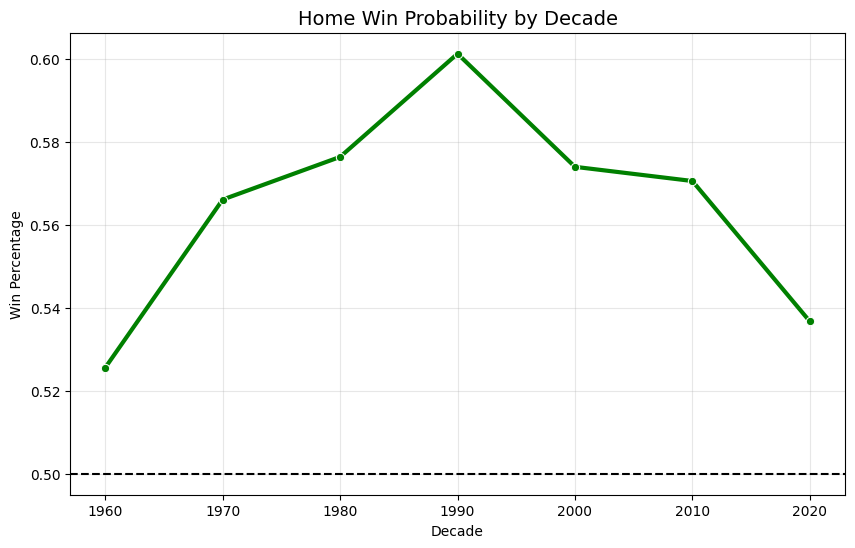

In [30]:
# Create a decade column
#  It uses integer division (//) to find the start of the decade for each season (e.g., 1974 becomes 1970)
df_clean['decade'] = (df_clean['schedule_season'] // 10) * 10

# Calculate win percentage by decade
decade_wins = df_clean.groupby('decade')['home_win'].mean().reset_index()

#  Sets the width of the graph to 10 inches and the height to 6 inches for better visibility
plt.figure(figsize=(10, 6))

# Uses the decade_wins data, plotting decade on the x-axis and home_win percentage on the y-axis, using green circles (marker='o') for each data point.
sns.lineplot(data=decade_wins, x='decade', y='home_win', marker='o', color='green', linewidth=3)

# This provides a "baseline" to show when home teams win more than half their games (anything above the dashed line).
plt.axhline(0.5, color='black', linestyle='--')

# Adds a title to the top of the chart.
plt.title('Home Win Probability by Decade', fontsize=14)

#  Labels the horizontal axis "Decade.
plt.xlabel('Decade')

# Labels the vertical axis "Win Percentage
plt.ylabel('Win Percentage')

# The alpha=0.3 makes the grid lines faint so they don't distract from the main data line.
plt.grid(True, alpha=0.3)
plt.show()

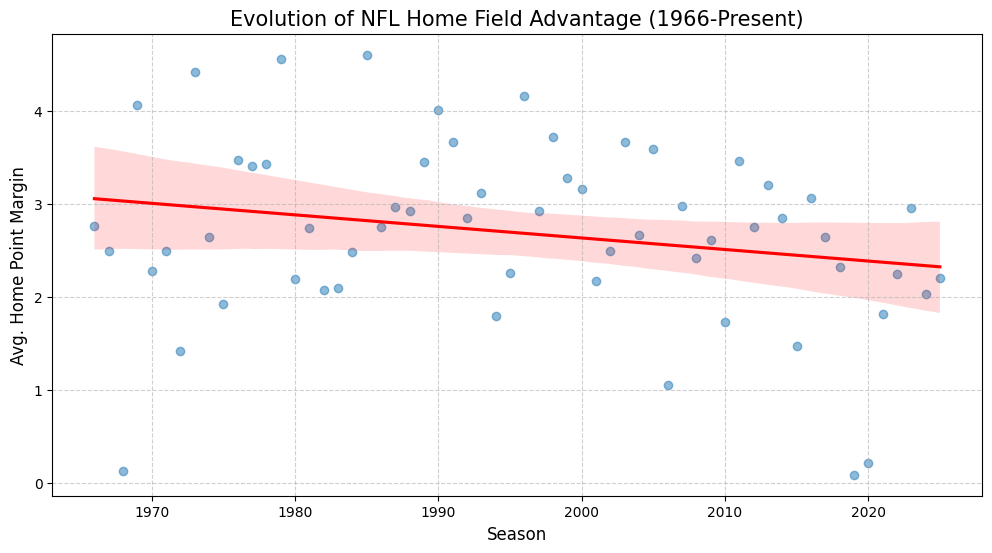

In [31]:
# Visualization 1: Evolution of the Home Margin
# Sets the width to 12 inches and the height to 6 inches to ensure the plot is clear and readable.
plt.figure(figsize=(12, 6))

#  It uses the seasonal_trends dataset, plotting the schedule_season on the x-axis and the average home_margin on the y-axis to show long-term trends.
sns.regplot(data=seasonal_trends, x='schedule_season', y='home_margin', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

# Clearly labels what the data represents and sets the font size to 14 for emphasis.
plt.title('Evolution of NFL Home Field Advantage (1966-Present)', fontsize=15)

#Identifies the time unit being measured as "Season."
plt.xlabel('Season', fontsize=12)

# Explains that the vertical scale represents the average points a home team wins by.
plt.ylabel('Avg. Home Point Margin', fontsize=12)

# Uses dashed lines (--) with slight transparency to make it easier to track specific data points against the axes
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\Jacob.Makowski\AppData\Local\Temp\ipykernel_5116\3910637337.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='schedule_season', y='home_win', palette=colors)


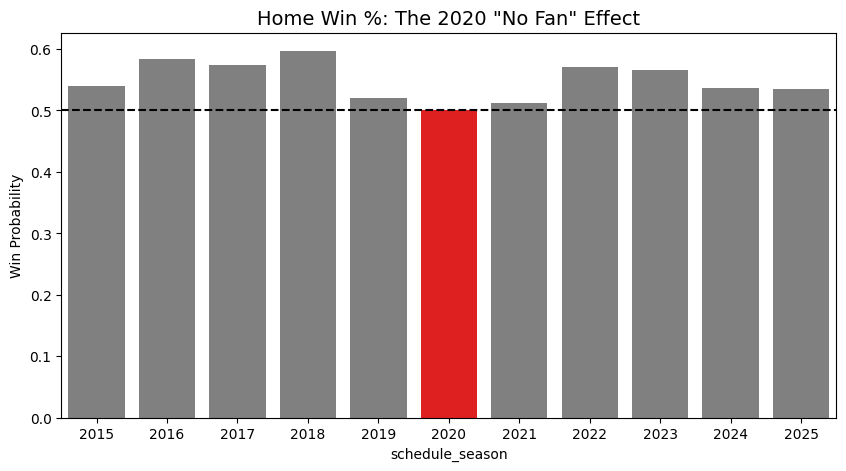

In [32]:
# Filter for recent years to highlight the 2020 anomaly
# Creates a new dataset containing only games from 2015 onwards
recent_years = df_clean[df_clean['schedule_season'] >= 2015]

# Groups those recent years by season and finds the average win percentage for home teams.
comparison = recent_years.groupby('schedule_season')['home_win'].mean().reset_index()

# Sets the size of the bar chart to 10x5 inches
plt.figure(figsize=(10, 5))

# Creates a list of colors where every year is grey except for 2020, which is set to red.
colors = ['grey' if x != 2020 else 'red' for x in comparison['schedule_season']]

# Generates a bar plot using the calculated win percentages and the custom color list.
sns.barplot(data=comparison, x='schedule_season', y='home_win', palette=colors)

# Draws a dashed horizontal line at the 50% mark (0.50) to show the "break-even" point where home teams win exactly half their games
plt.axhline(0.50, color='black', linestyle='--')

# Adds the title to the chart with a font size of 14
plt.title('Home Win %: The 2020 "No Fan" Effect', fontsize=14)

#  Labels the vertical axis as "Win Probability."
plt.ylabel('Win Probability')
plt.show()